In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from aux_func import get_data
from epiweeks import Week 

Load data:

In [2]:
challenge = 'dengue_state'

df_dengue_state = get_data(challenge)
df_dengue_state.date = pd.to_datetime(df_dengue_state.date)

df_dengue_state = df_dengue_state.loc[df_dengue_state.date >= pd.to_datetime(Week(2022, 41).startdate())]

df_dengue_state.head()

,date,adm_1,casos
17982,2022-10-09,11,99
17983,2022-10-09,12,31
17984,2022-10-09,13,250
17985,2022-10-09,14,2
17986,2022-10-09,15,60


Load preds: 

In [3]:
df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [4]:
df_preds.model.value_counts()

model
3rd_imdc_fiocruz_mard                                             5643
3rd_imdc_lncc_lncc_arp26_dengue                                   5643
DS-OKSTATE-2026                                                   5643
3rd_imdc_lncc_surge_model26_dengue                                5643
3rd_imdc_emap_lstm                                                5643
3rd_imdc_lncc_clidengo26dengue                                    5643
3rd_imdc_cornell_bentolab                                         5643
3rd_imdc_rki_rki_zki_ph                                           5643
3rd_imdc_procc_bb_model                                           5591
3rd_imdc_isi_isi-dengue                                           5434
3rd_imdc_purdue_neuralearth                                       5434
3rd_imdc_bsc_ghr                                                  5434
3rd_imdc_fgv_pattern-blue                                         5434
3rd_imdc_unesp_recogna                                            5434


Load rank: 

In [5]:
df_rank = pd.read_csv('predictions/rank_ratio.csv.gz')

df_summary = (
    df_rank
    .groupby(["adm_1", "model"], as_index=False)
    .agg(
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    )
    .sort_values(["adm_1", "geometric_mean_ratio"])
)

df_summary.head()

,adm_1,model,geometric_mean_ratio
5,11,3rd_imdc_emap_epidematicos_sarimax_state,0.769598
19,11,3rd_imdc_pucrio_arbocaster,0.789304
15,11,3rd_imdc_lncc_lncc_arp26_dengue,0.800598
12,11,3rd_imdc_ifgw_inframind-proteus,0.845450
22,11,3rd_imdc_rki_rki_zki_ph_lstm_geo,0.900748


GO: 

In [ ]:
def plot_comp_states(state, df_dengue_state, df_preds): 

    df_dengue = df_dengue_state.loc[df_dengue_state.adm_1 == state]

    df_preds_st = df_preds.loc[df_preds.adm_1 == state]

    best_models = list(df_summary.loc[(df_summary.adm_1 == state) & (df_summary.geometric_mean_ratio < 1)].model.values)

    model_base = '3rd_imdc_procc_bb_model'

    best_models.append(model_base)

    _,ax = plt.subplots(figsize = (10, 4))

    ax.plot(df_dengue.date, df_dengue.casos, color = 'black', marker = '.', zorder = 5)

    for model in df_preds.model.unique():

        df_ = df_preds_st.loc[df_preds_st.model == model].sort_values(by = 'date') 

        if model in best_models: 
            ax.plot(df_.date, df_.pred, label = model, zorder = 6, linewidth = 2)

        else:
            ax.plot(df_.date, df_.pred, color = 'tab:grey', alpha= 0.2)


    ax.legend()

    ax.grid()
    ax.set_title(code_to_state[state])

    plt.show()


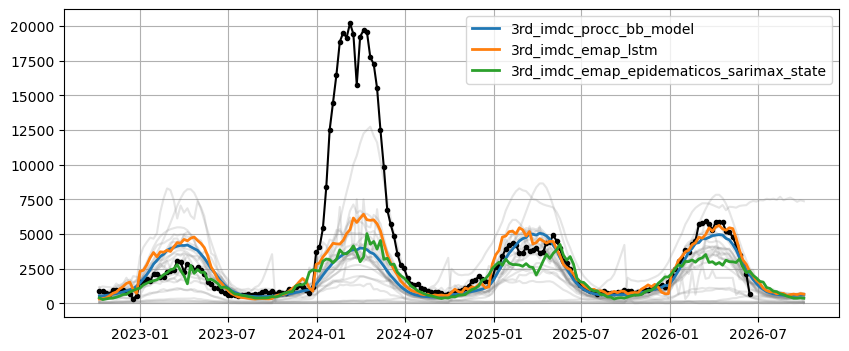

In [8]:
_,ax = plt.subplots(figsize = (10, 4))

ax.plot(df_dengue.date, df_dengue.casos, color = 'black', marker = '.', zorder = 5)

for model in df_preds.model.unique():

    df_ = df_preds_st.loc[df_preds_st.model == model].sort_values(by = 'date') 

    if model in best_models: 
        ax.plot(df_.date, df_.pred, label = model, zorder = 6, linewidth = 2)

    else:
        ax.plot(df_.date, df_.pred, color = 'tab:grey', alpha= 0.2)


ax.legend()

ax.grid()

plt.show()